In [ ]:
# -*- coding: utf-8 -*-
#  Copyright 2026 United Kingdom Research and Innovation
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#  Authored by:    Laura Murgatroyd (UKRI-STFC)

# Duplicate Angle
This notebook briefly showcases the impact a duplicate angle can have on FBP reconstruction



In [ ]:
import numpy as np
import os

from cil.utilities.display import show2D
from cil.plugins.astra import FBP as FBP_ASTRA
from cil.processors import Slicer

from data_io.io import read_mantid_imaging_data
from recon.weighted_fbp import  run_weighted_fbp_parallel

### Data

This notebook uses a dataset of a lego man imaged at IMAT. The lego man is inside a lead container.

Here we use the data acquired using the Equidistant protocol: with angles incrementally increased by the same amount and rotated through a total of 360 degrees.

You will need to download the dataset `preprocessed_data.zip` from https://zenodo.org/records/17814677:

    https://zenodo.org/records/17814677/files/preprocessed_data.zip

Please update the filepath below:

In [30]:
# Update this path to where you have downloaded the data:
base_path = "/home/lhe97136/Data/Lego GR Investigation/Data for Release/preprocessed_data/"

Here we load in data which has already been preprocessed in Mantid Imaging:

In [ ]:
# pixel size in cm, which is listed on the zenodo page:
pixel_size = 100*10**-4
equi_full = read_mantid_imaging_data(os.path.join(base_path, "Equidistant"), pixel_size=pixel_size)

### Identifying the Angular Spacing

Here we print the first 10 angles and last 10 angles:

In [32]:
angles = equi_full.geometry.angles
print("First 10 angles (degrees): ", angles[:10])
print("Last 10 angles (degrees): ", angles[-10:])

First 10 angles (degrees):  [0.     0.7877 1.5754 2.3631 3.1508 3.9385 4.7262 5.5139 6.3016 7.0893]
Last 10 angles (degrees):  [352.8896 353.6773 354.465  355.2527 356.0404 356.8281 357.6158 358.4035
 359.1912 359.9789]


Let's look at the spacing between each angle:

In [33]:
angle_spacing=np.diff(angles)
mean_spacing = np.mean(angle_spacing)
print("Mean angle spacing (degrees): ", mean_spacing)
print("All angular spacing approx equal to mean? ", np.all(np.isclose(angle_spacing, mean_spacing, atol=1e-4)))

Mean angle spacing (degrees):  0.7877
All angular spacing approx equal to mean?  True


The angular spacing between all of the angles is approx 0.7877 degrees. Except what about the final angle?
The final angle is close to 360 degrees, which means its very close to the first angle which was acquired at 0 degrees. But just how close?

In [34]:
final_ang_diff = (angles[0]-angles[-1]) % 360
print("Difference between last and first angle: ", final_ang_diff)
print(f"This is {(final_ang_diff / mean_spacing)*100:.1f}% of the mean angular spacing, so significantly smaller!")

Difference between last and first angle:  0.021087646484375
This is 2.7% of the mean angular spacing, so significantly smaller!


The difference between the last and first angle is so small that it's effectively a duplicate projection at the same angle.

### Reconstruction

So does this have an impact on the reconstruction?
Let's compare a standard FBP reconstruction and a weighted FBP reconstruction. In weighted FBP, the projections are weighted proportional to the spacing between the previous and following angle. So this would mean projections closer together in angle are weighted less than those further apart.

/home/lhe97136/CIL-IMAT-Correct/IMAT-Demos/recon/weighted_fbp.py:114: UserWarning: Because max_gap was None, it has been set to double the mean of all gaps between angles: 0.7860 degree
  return _calculate_angular_sampling_weights(data, 180, max_gap, wedge_behaviour)


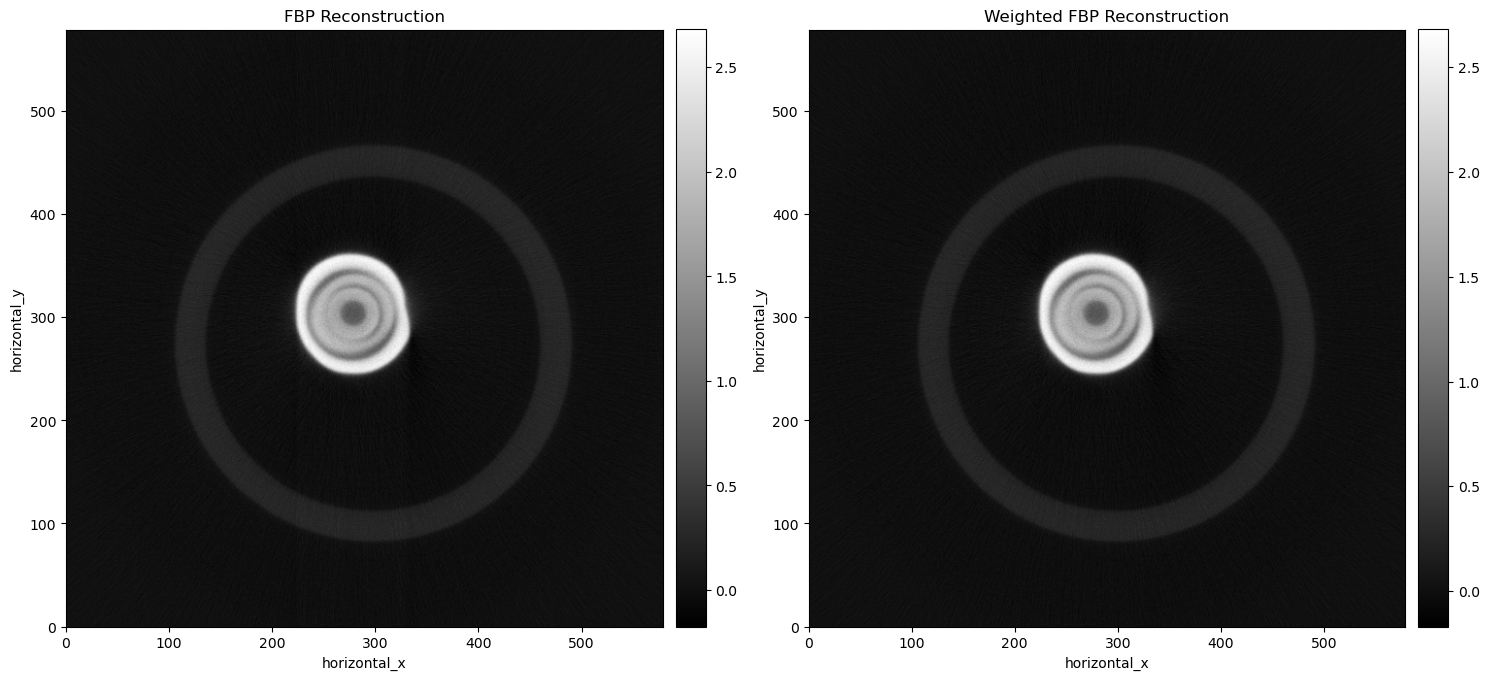

In [ ]:
data_slice = equi_full.get_slice(vertical=317)
data_slice.reorder('astra')
recon_fbp = FBP_ASTRA(None, data_slice.geometry)(data_slice)
recon_weighted = run_weighted_fbp_parallel(data_slice)
show2D([recon_fbp, recon_weighted], title=['FBP Reconstruction', 'Weighted FBP Reconstruction'], cmap='grey', num_cols=2)

Can you tell that by weighting the reconstruction we have got rid of some vertical stripes?
This can be seen more clearly by taking a difference of the two reconstructions.

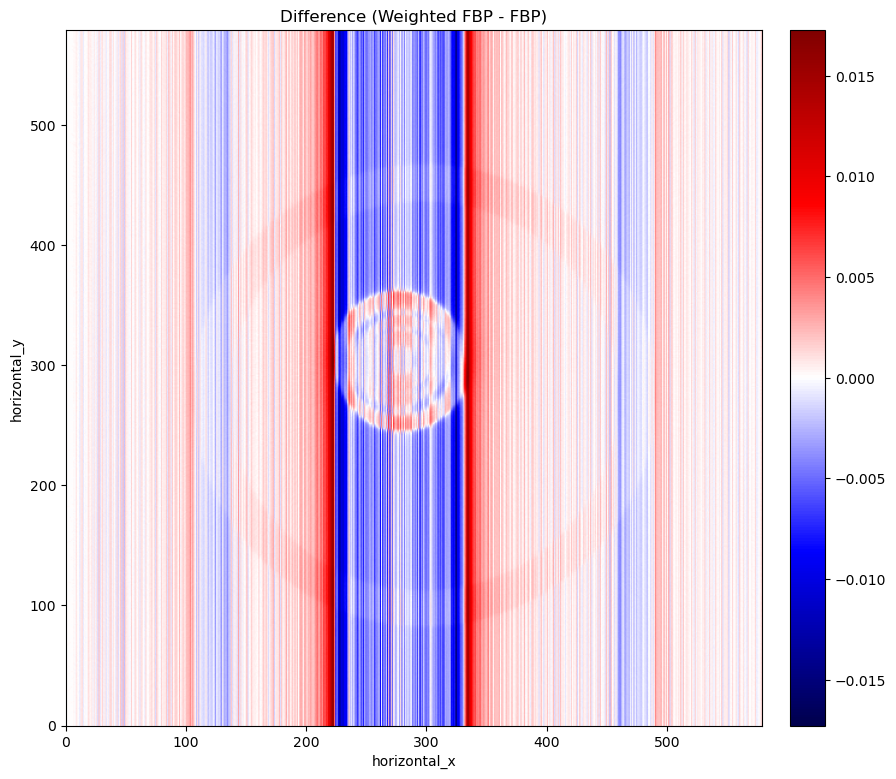

In [36]:
diff = recon_weighted-recon_fbp
max_diff = np.max(diff)
show2D(diff, cmap='seismic', title='Difference (Weighted FBP - FBP)', fix_range=(-max_diff, max_diff))

In [37]:
print(f"The maximum difference is {max_diff/np.max(recon_fbp)*100:.2f}% of the max value in the FBP reconstruction.")

The maximum difference is 0.64% of the max value in the FBP reconstruction.


This is small, but is clearly significant seeing as it can be seen by eye in the reconstruction!

Note that the artifact can similarly be removed by simply removing the final projection from the data before reconstructing:

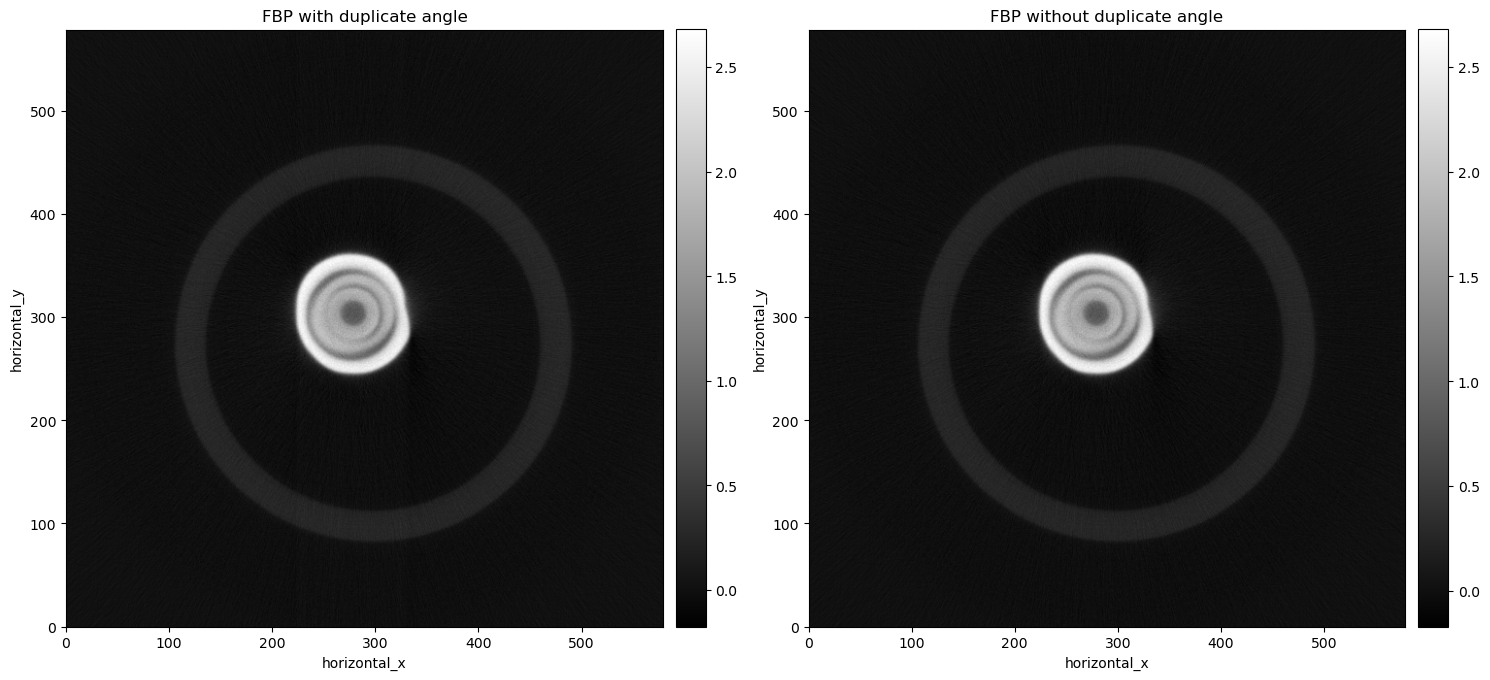

In [38]:
data_slice_cut = Slicer(roi={'angle':(0,-1)})(data_slice)
fbp_cut = FBP_ASTRA(None, data_slice_cut.geometry)(data_slice_cut)
show2D([recon_fbp, fbp_cut], title=['FBP with duplicate angle', 'FBP without duplicate angle'], cmap='grey', num_cols=2)

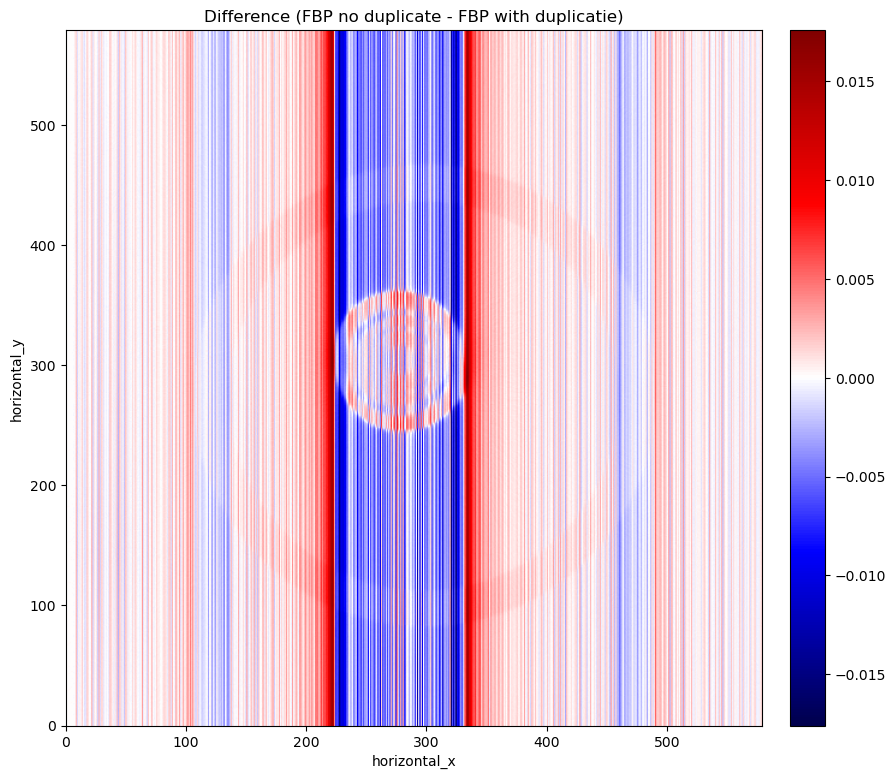

In [39]:
diff2 = fbp_cut-recon_fbp
max_diff2 = np.max(diff2)
show2D(diff2, cmap='seismic', title='Difference (FBP no duplicate - FBP with duplicatie)', fix_range=(-max_diff2, max_diff2))